# Chapter 19: Frank Bass and the Television
Compute Bass adoption and incidence, fit sparse data, and show why early curves
cannot identify a market ceiling confidently. All observations are synthetic.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.optimize import least_squares
rng=begin(19)
def bass(t,p,q,m):
    e=np.exp(-(p+q)*np.asarray(t)); return m*(1-e)/(1+q/p*e)
t=np.linspace(0,30,301); p,q,m=.025,.35,100000
adopt=bass(t,p,q,m); assert np.all(np.diff(adopt)>=0) and adopt.max()<=m

## Cumulative adoption bends toward a ceiling
The Bass curve has three inputs: p, the rate at which people adopt on their own
(innovation), q, the rate at which adoption spreads from adopters to the rest
(imitation), and m, the eventual number of adopters. Both rates are per year
here. Only m sets the height of the curve; p and q set its shape and timing.

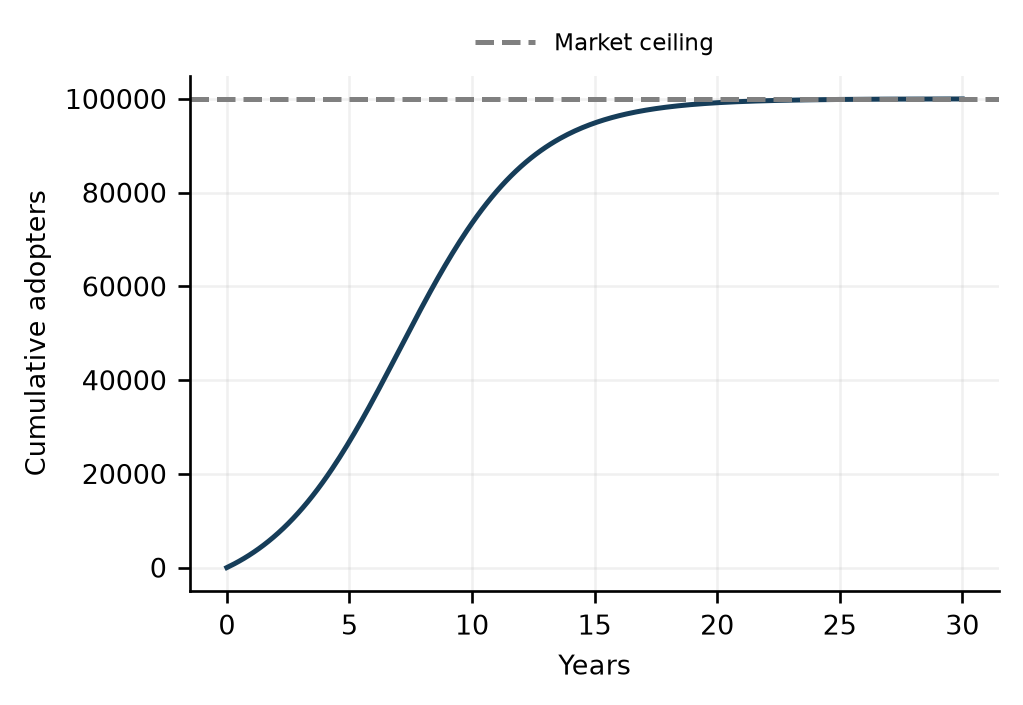

In [2]:
plt.figure(); plt.plot(t,adopt); plt.axhline(m,ls='--',color='.5',label='Market ceiling'); plt.xlabel('Years'); plt.ylabel('Cumulative adopters'); plt.legend()
save(19,1,'Adoption accumulates toward a ceiling','Synthetic Bass curve with p=0.025/year, q=0.35/year and a 100,000-adopter ceiling. Parameters are rates, not population fractions.','## Section Two: The Pre-Launch Problem')

## New adopters per year peak before the market saturates
Incidence is the derivative of the cumulative curve. When q exceeds p the peak
comes at log(q/p)/(p+q) years: about 7.0 years for these rates, and independent
of m. A bigger market ceiling raises the peak but does not move it.

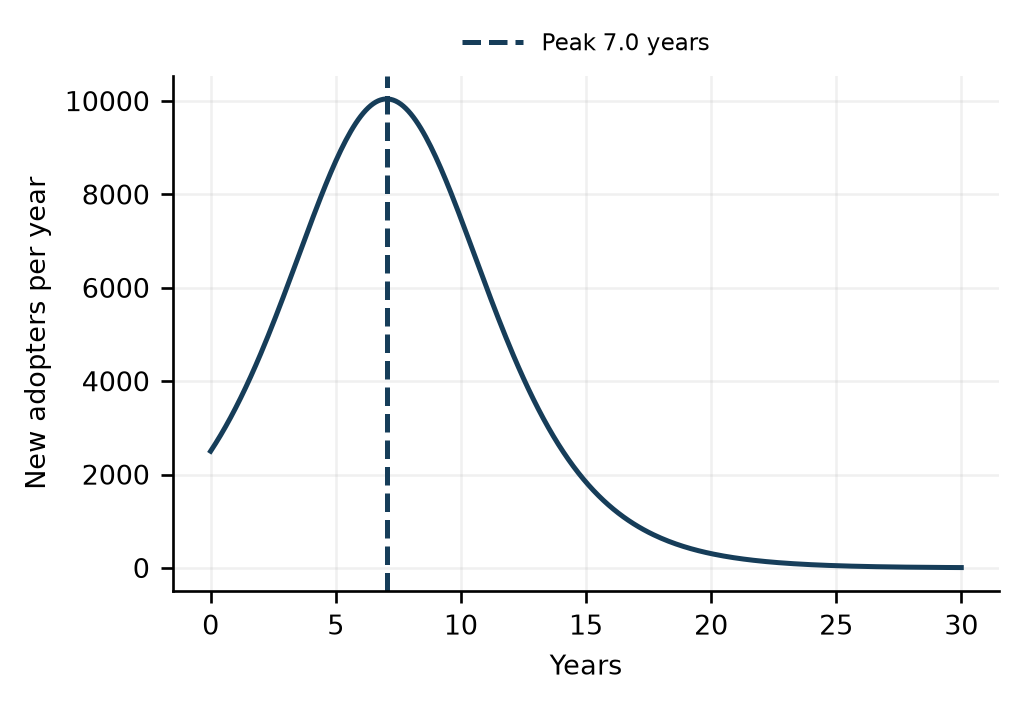

In [3]:
incidence=(p+q*adopt/m)*(m-adopt); peak=np.log(q/p)/(p+q)
plt.figure(); plt.plot(t,incidence); plt.axvline(peak,ls='--',label=f'Peak {peak:.1f} years'); plt.xlabel('Years'); plt.ylabel('New adopters per year'); plt.legend()
save(19,2,'The adoption rate peaks before saturation','Derivative of the synthetic cumulative curve. The interior peak formula applies when q is greater than p; the ceiling scales volume, not peak timing.','## Section Three: From Television to TikTok')

## A sparse early history allows very different futures
Fix alternative ceilings and fit p,q on only the first five years. Similar
early fits are not evidence that their extrapolations are equally credible.

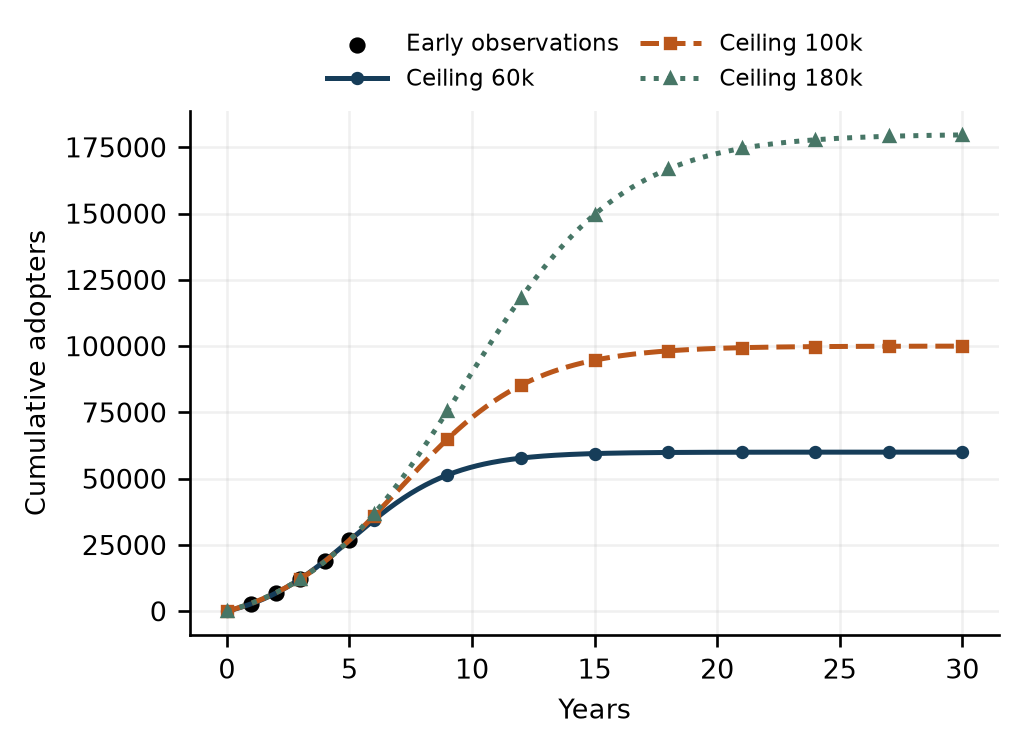

In [4]:
early=np.arange(1,6); observed=bass(early,p,q,m)+rng.normal(0,200,5)
plt.figure(); plt.scatter(early,observed,color='black',s=15,label='Early observations')
for ceiling in [60000,100000,180000]:
    fit=least_squares(lambda pars:(bass(early,*pars,ceiling)-observed)/1000,[.03,.3],bounds=([.001,.001],[.2,1.]))   # residuals in thousands keep the optimizer well scaled
    plt.plot(t,bass(t,*fit.x,ceiling),label=f'Ceiling {ceiling/1000:.0f}k')
plt.xlabel('Years'); plt.ylabel('Cumulative adopters'); plt.legend(fontsize=7)
save(19,3,'Early fits can hide ceiling uncertainty','Synthetic five-point calibration with three assumed market ceilings. These are sensitivity scenarios, not a calibrated prediction band.','## Section Four: The Full Methodology')

## Adoption is not sales: trial and repeat
The chapter's trial-and-repeat arithmetic, with illustrative numbers: 100,000
households, half aware, one fifth of the aware trying (10,000 triers), 1.2 units
per trial. Thirty percent of triers repeat, buying four times a year at 1.4 units
per purchase. Repeat volume (16,800 units) exceeds trial volume (12,000) even
though only a third of triers come back: repeat is where durable sales live.

In [5]:
households, awareness, trial_given_aware = 100000, .5, .2
trial_households = households*awareness*trial_given_aware
units_per_trial, repeat_share, purchases_per_year, units_per_repeat = 1.2, .3, 4, 1.4
trial_volume = trial_households*units_per_trial
repeat_volume = trial_households*repeat_share*purchases_per_year*units_per_repeat
print(f'triers {trial_households:,.0f}; trial units {trial_volume:,.0f}; repeat units {repeat_volume:,.0f}')

triers 10,000; trial units 12,000; repeat units 16,800


## Limits and exercise
Add mature observations and refit. Durable first adoption differs from recurring
purchases: incidence alone is not total recurring sales. A repeat-purchase model
needs cohort retention/cadence. Generalized Bass, conjoint and agent networks are
extensions with additional data/identification requirements.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
Cumulative unique adopters at six or more increasing times, with `ceilings` naming at least one defended market ceiling above the observed total. `repeat_kernel` lists expected repeat units per original trier at cohort ages one, two, three and so on; `units_at_trial` is the first-purchase quantity. `parfitt_collins` takes `T` (eventual trial share), `R` (repeat share) and optional `B` (buying-rate index).

Minimal **format illustration**, not sufficient training data:

```csv
time,adopters
1,2944
2,6931
3,12179
4,18839
```

## Explain the mechanism

Bass separates external adoption pressure p from imitation pressure q times existing penetration. Remaining nonadopters limit growth. Its familiar S-shape is a model of first adoption, not a universal sales law.

## Work through the arithmetic

With m=10,000, existing adopters N=2,000, p=.02/year and q=.3/year, instantaneous adoption rate is (.02+.3×.2)×8,000=640 adopters/year. If q>p, peak time is log(q/p)/(p+q); here log(15)/.32≈8.463 years under a launch at zero adoption.

## Adapt the lesson to reader data

Replace early/observed in the sparse-fit block with elapsed time and cumulative unique adopters. Select ceiling scenarios from external market definitions, not simply from whichever fit pleases the sponsor. Keep repeat-volume arithmetic separate.

For this chapter, settle these questions before fitting: Does the series count cumulative unique adopters? What is the market ceiling’s evidence? Are time units consistent? Has the inflection or peak been observed? What repeat behavior lies outside adoption?

## Interpret the actual lesson outputs

The lesson contrasts cumulative adoption with its derivative and fits the first five synthetic years under different ceilings. Similar early fits expose weak identification; they do not assign probabilities to ceilings. Trial/repeat figures use separately assumed purchase factors.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `time,ceiling,bass_trials,gamma_trials,bass_units,gamma_units`.
- `summary.json`: `fits,ceilings,sales_horizon,peak,kernel,timing_comparison,parfitt_collins,bass_table_rows` plus method, interpretation, assumptions, not_done and status.

The tool fits the Bass model for each declared ceiling (with early-fit holdout, Jacobian condition and peak time), optionally refits with `fix_q` held, then converts adoption into sales over `sales_horizon` periods (24 or more) under two timing curves that share the same trial total: Bass incidence and the author's gamma-shaped launch curve with its `peak` month. Each timing is spread with the repeat kernel into unit sales, and the tool compares peak period, twelve-period units and total units between them. With `parfitt_collins` inputs it reports the steady-state share and a plus or minus 20 percent band on repeat. Price, distribution and advertising are not in the curve; the kernel is assumed, not estimated. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Early adoption often weakly identifies m and can trade off with p,q. An interior incidence peak formula requires q>p. Saturation is a structural assumption, not proof that the market cannot expand. Scenario curves are not a calibrated interval.

With no adoption history use defended analogue parameters and explicit scenarios. With only sales units, obtain unique-adopter/cohort information or change the target; do not treat cumulative repeat sales as cumulative adoption.

The applied deliverable must make these items inspectable: `results.csv` columns: `time,ceiling,bass_trials,gamma_trials,bass_units,gamma_units`; `summary.json` keys: `fits,ceilings,sales_horizon,peak,kernel,timing_comparison,parfitt_collins,bass_table_rows` plus method, interpretation, assumptions, not_done and status. Show both timing curves; the same eventual total can put half the first year in a different quarter.

## Three exercises with worked solutions

### Exercise 1

p=.01,q=.2,m=1000,N=100: incidence?

**Worked solution.** (.01+.2×.1)×900=27 adopters per time unit.

### Exercise 2

If q<=p, should a negative interior peak time be forecast?

**Worked solution.** No. The interior formula does not describe a future peak; incidence is highest at or near launch under the basic model.

### Exercise 3

Cumulative sales are 10,000 but include three purchases per buyer. Are there 10,000 adopters?

**Worked solution.** No. Unique adopter counts require separate evidence; repeat units cannot be silently equated with adoption.

## Business-reader application

Use this request with the skill:

> Apply chapter 19 to adoption.csv, defend several market ceilings and show which long-run differences are unsupported by the early history.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch19.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch19.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(19, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch19-workshop-results.csv', index=False)
_ = (workshop_output/'ch19-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Bass diffusion with sales conversion under two timing curves
Status: passed

Interpretation: Alternative ceilings are sensitivity scenarios, not probability bounds. Large Jacobian condition numbers warn of weak local identification. First adoption is not recurring sales. Sales layer: over 24 months the same trial total (63911 at ceiling 150000) peaks in period 1 under Bass timing and period 5 under the 4-peak launch curve; 12-period units 138093 vs 112589. Timing assumptions change the year-one number even when the eventual total is identical. Parfitt-Collins steady-state share 8.3% (band 6.7% to 10.0%).

Assumptions:
  - Cumulative adopters follow a Bass curve for each declared ceiling
  - Each trier buys units_at_trial at first purchase and the repeat kernel afterwards
  - Launch-curve peak month is a judgment input
  - sales_horizon (24 or more periods) is separate from the Bass table horizon
Not done:
  - No price, distribution or advertising drivers in the adoption curve
 

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **What ceiling did I assume, and how different is the forecast under the other defensible ceilings?**
   A bad answer looks like this: Early adoption data cannot identify the ceiling; the ceiling is a judgment and the fan must show it.

2. **Am I forecasting first adoption or sales, and did I add repeat purchasing where the product is bought again?**
   A bad answer looks like this: A Bass curve reported as a sales forecast for a repeat-purchase product misses most of the volume.

3. **Does the timing of the peak follow from the parameters, or from a launch curve I imposed?**
   A bad answer looks like this: Two timing assumptions with the same total give different first years; the report must say which one is used.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).